# Reconstructing an ECG from PyHEARTS Gaussians

This notebook walks through the reconstruction path end to end:

1. **Original signal** — a short noisy synthetic ECG
2. **PyHEARTS features** — per-beat P/Q/R/S/T Gaussians and fiducials
3. **Reconstruction process** — each wave as a Gaussian, placed on the recording's sample/time axis
4. **Quality** — original vs the Gaussian mixture, with correlation and error metrics

Install the toolbox first (simulation needs the optional `sim` extra):

```bash
pip install "pyhearts[sim]"
```

The morphological reconstruction is the **sum of fitted Gaussians** (`recon.gaussian`).
If residual noise from the original is added back, `recon.signal` equals the original
by construction — that is the additive model, not a second quality check. Quality
metrics below compare the original trace to `recon.gaussian`.


## 1. Simulate a short ECG

NeuroKit2 provides a clean morphological template. We add modest Gaussian noise so
the residual is visible and reconstruction quality is not trivially perfect.


In [1]:
import matplotlib.pyplot as plt
import neurokit2 as nk
import numpy as np
import pandas as pd

import pyhearts
from pyhearts import PyHEARTS, reconstruct_ecg
from pyhearts.processing.reconstruct import reconstruct_cycle

SAMPLING_RATE_HZ = 500.0
DURATION_S = 12
HEART_RATE_BPM = 70
SEED = 7
NOISE_SD = 0.04

WAVE_COLORS = {
    "P": "#6A4CFF",
    "Q": "#2A9D8F",
    "R": "#E63946",
    "S": "#F4A261",
    "T": "#457B9D",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})

rng = np.random.default_rng(SEED)
clean = np.asarray(
    nk.ecg_simulate(
        duration=DURATION_S,
        sampling_rate=int(SAMPLING_RATE_HZ),
        heart_rate=HEART_RATE_BPM,
        random_state=SEED,
    ),
    dtype=float,
)
ecg = clean + rng.normal(0.0, NOISE_SD, size=clean.size)
time_s = np.arange(ecg.size) / SAMPLING_RATE_HZ

print(f"PyHEARTS {pyhearts.__version__}")
print(
    f"signal: {ecg.size} samples "
    f"({ecg.size / SAMPLING_RATE_HZ:.1f} s @ {SAMPLING_RATE_HZ:g} Hz), "
    f"added N(0, {NOISE_SD}) noise"
)


PyHEARTS 1.0.0
signal: 6000 samples (12.0 s @ 500 Hz), added N(0, 0.04) noise


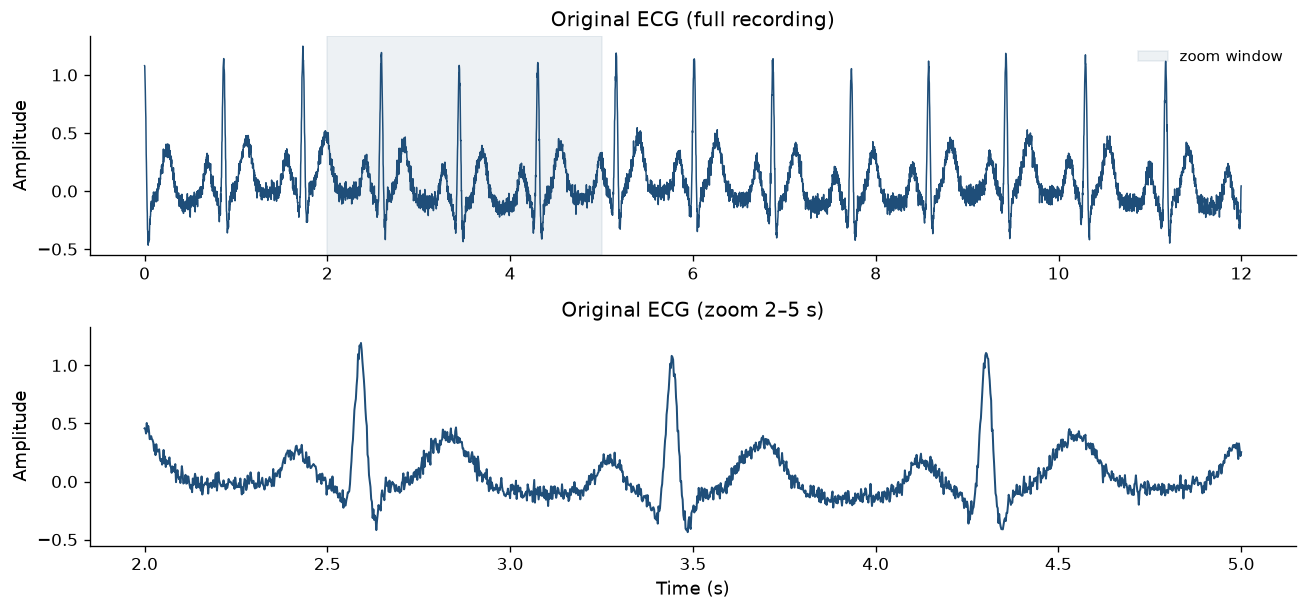

In [2]:
ZOOM = (2.0, 5.0)  # seconds — used again in later figures

fig, axes = plt.subplots(2, 1, figsize=(11, 5.2), sharey=True)
axes[0].plot(time_s, ecg, color="#1f4e79", lw=0.9)
axes[0].axvspan(*ZOOM, color="#1f4e79", alpha=0.08, label="zoom window")
axes[0].set_title("Original ECG (full recording)")
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc="upper right", frameon=False)

mask = (time_s >= ZOOM[0]) & (time_s <= ZOOM[1])
axes[1].plot(time_s[mask], ecg[mask], color="#1f4e79", lw=1.2)
axes[1].set_title(f"Original ECG (zoom {ZOOM[0]:.0f}–{ZOOM[1]:.0f} s)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
fig.tight_layout()
plt.show()


## 2. Run PyHEARTS

`species="human"` selects the production human pipeline. We filter the raw trace
with `preprocess_signal`, then extract beat-level Gaussian morphology with
`analyze_ecg`.


In [3]:
analyzer = PyHEARTS(sampling_rate=SAMPLING_RATE_HZ, species="human")

filtered = analyzer.preprocess_signal(
    ecg,
    highpass_cutoff=0.5,
    lowpass_cutoff=50.0,
    filter_order=4,
    notch_frequency=60.0,
    quality_factor=30.0,
)

features, cycles = analyzer.analyze_ecg(filtered)
time_s = np.arange(filtered.size) / SAMPLING_RATE_HZ

print(f"detected {len(features)} cardiac cycles, {features.shape[1]} features each")
print(f"median per-cycle fit R²: {features['r_squared'].median():.3f}")
print(f"median per-cycle RMSE:   {features['rmse'].median():.4f}")


detected 13 cardiac cycles, 136 features each
median per-cycle fit R²: 0.972
median per-cycle RMSE:   0.0412


## 3. Inspect PyHEARTS features

Each row is one beat. Gaussian parameters (`*_gauss_center`, `*_gauss_height`,
`*_gauss_stdev_samples`) are the quantities reconstruction uses. Global sample
indices place those Gaussians on the recording so beats keep their relative
timing. `T_gaussian_global_center_idx` is the morphology T center;
`T_global_center_idx` is the record-level T fiducial.


In [4]:
preview_cols = [
    "P_gauss_height", "P_gauss_stdev_ms",
    "R_gauss_height", "R_gauss_stdev_ms",
    "T_gauss_height", "T_gauss_stdev_ms",
    "P_global_center_idx", "R_global_center_idx",
    "T_gaussian_global_center_idx", "T_global_center_idx",
    "RR_interval_ms", "r_squared", "rmse",
]
preview = features[[c for c in preview_cols if c in features.columns]].copy()
display(preview.round(3))


,P_gauss_height,P_gauss_stdev_ms,R_gauss_height,R_gauss_stdev_ms,T_gauss_height,T_gauss_stdev_ms,P_global_center_idx,R_global_center_idx,T_gaussian_global_center_idx,T_global_center_idx,RR_interval_ms,r_squared,rmse
cycle_index,,,,,,,,,,,,,
0,0.497,76.000,1.393,14.630,0.571,78.904,341,433,557,559.0,NaN,0.970,0.045
1,0.397,60.000,1.222,12.225,0.457,62.000,778,866,987,992.0,866.0,0.893,0.097
2,0.318,48.000,1.256,12.398,0.465,55.853,1210,1295,1410,1420.0,858.0,0.963,0.047
3,0.287,38.000,1.229,12.528,0.491,60.315,1636,1722,1846,1847.0,854.0,0.969,0.046
4,0.310,40.501,1.262,12.259,0.470,56.649,2063,2152,2267,2277.0,860.0,0.965,0.046
5,0.321,36.387,1.237,12.452,0.487,62.177,2491,2580,2694,2703.0,856.0,0.972,0.041
6,0.332,41.928,1.247,12.458,0.490,63.685,2921,3007,3132,3132.0,854.0,0.972,0.039
7,0.340,39.958,1.262,12.656,0.488,59.320,3350,3437,3561,3562.0,860.0,0.980,0.034
8,0.308,38.917,1.238,12.643,0.473,60.127,3781,3867,3981,3990.0,860.0,0.978,0.035


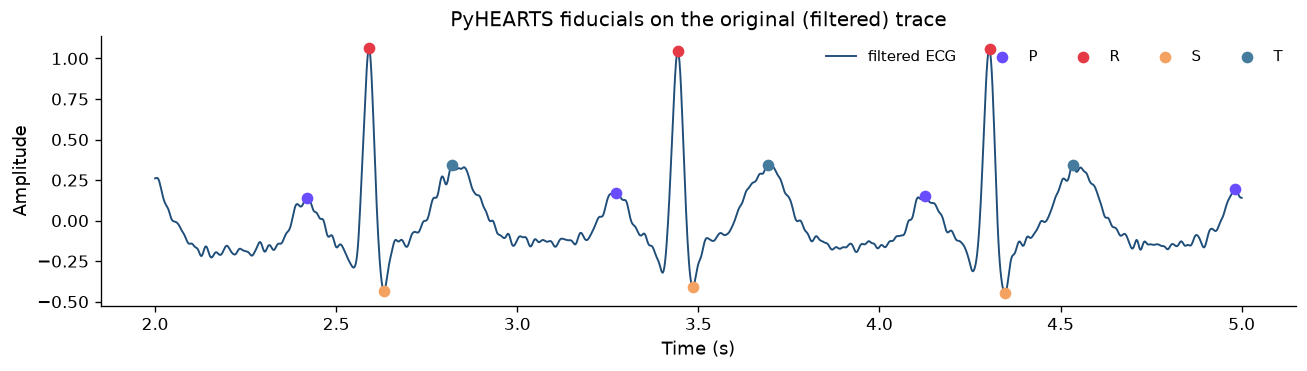

In [5]:
def scatter_fiducials(ax, feats, t, y, t0, t1):
    for wave, color in WAVE_COLORS.items():
        col = (
            "T_gaussian_global_center_idx"
            if wave == "T" and "T_gaussian_global_center_idx" in feats.columns
            else f"{wave}_global_center_idx"
        )
        if col not in feats.columns:
            continue
        idx = pd.to_numeric(feats[col], errors="coerce").to_numpy(dtype=float)
        idx = idx[np.isfinite(idx)]
        ts = idx / SAMPLING_RATE_HZ
        keep = (ts >= t0) & (ts <= t1)
        if not np.any(keep):
            continue
        samples = np.clip(np.round(idx[keep]).astype(int), 0, y.size - 1)
        ax.scatter(
            ts[keep],
            y[samples],
            s=36,
            color=color,
            zorder=3,
            label=wave,
        )


fig, ax = plt.subplots(figsize=(11, 3.2))
mask = (time_s >= ZOOM[0]) & (time_s <= ZOOM[1])
ax.plot(time_s[mask], filtered[mask], color="#1f4e79", lw=1.15, label="filtered ECG")
scatter_fiducials(ax, features, time_s, filtered, *ZOOM)
ax.set_title("PyHEARTS fiducials on the original (filtered) trace")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.legend(ncol=6, loc="upper right", frameon=False)
fig.tight_layout()
plt.show()


## 4. Reconstruction process

`reconstruct_ecg` evaluates each beat's P/Q/R/S/T Gaussians on the global sample
index (`recon.index`; `recon.time_ms` is the same axis in milliseconds).

We pass `add_noise=False` so the plotted reconstruction is the **clean Gaussian
mixture**. Residual noise from the original is still available as `recon.noise`
when an original trace is supplied.


In [6]:
recon = analyzer.reconstruct_ecg(original=filtered, add_noise=False)
recon_time_s = recon.time_ms / 1000.0

print(f"placed {recon.extras['n_components']} Gaussian components")
print(f"output length: {recon.gaussian.size} samples")
print("components per wave:")
print(recon.params.groupby("wave").size().reindex(list(WAVE_COLORS), fill_value=0).to_string())
display(recon.params.head(10).round(2))


placed 52 Gaussian components
output length: 6000 samples
components per wave:
wave
P    13
Q     0
R    13
S    13
T    13


,cycle_index,wave,mu,height,sigma,onset,offset
0,0,P,345.09,0.50,38.00,286.0,405.0
1,0,R,432.76,1.39,7.31,420.0,445.0
2,0,S,452.96,-0.07,3.00,NaN,NaN
3,0,T,550.00,0.57,39.45,488.0,612.0
4,1,P,774.92,0.40,30.00,728.0,822.0
5,1,R,866.50,1.22,6.11,856.0,877.0
6,1,S,887.93,-0.08,3.00,NaN,NaN
7,1,T,989.43,0.46,31.00,941.0,1038.0
8,2,P,1207.72,0.32,24.00,1170.0,1245.0
9,2,R,1294.88,1.26,6.20,1285.0,1305.0


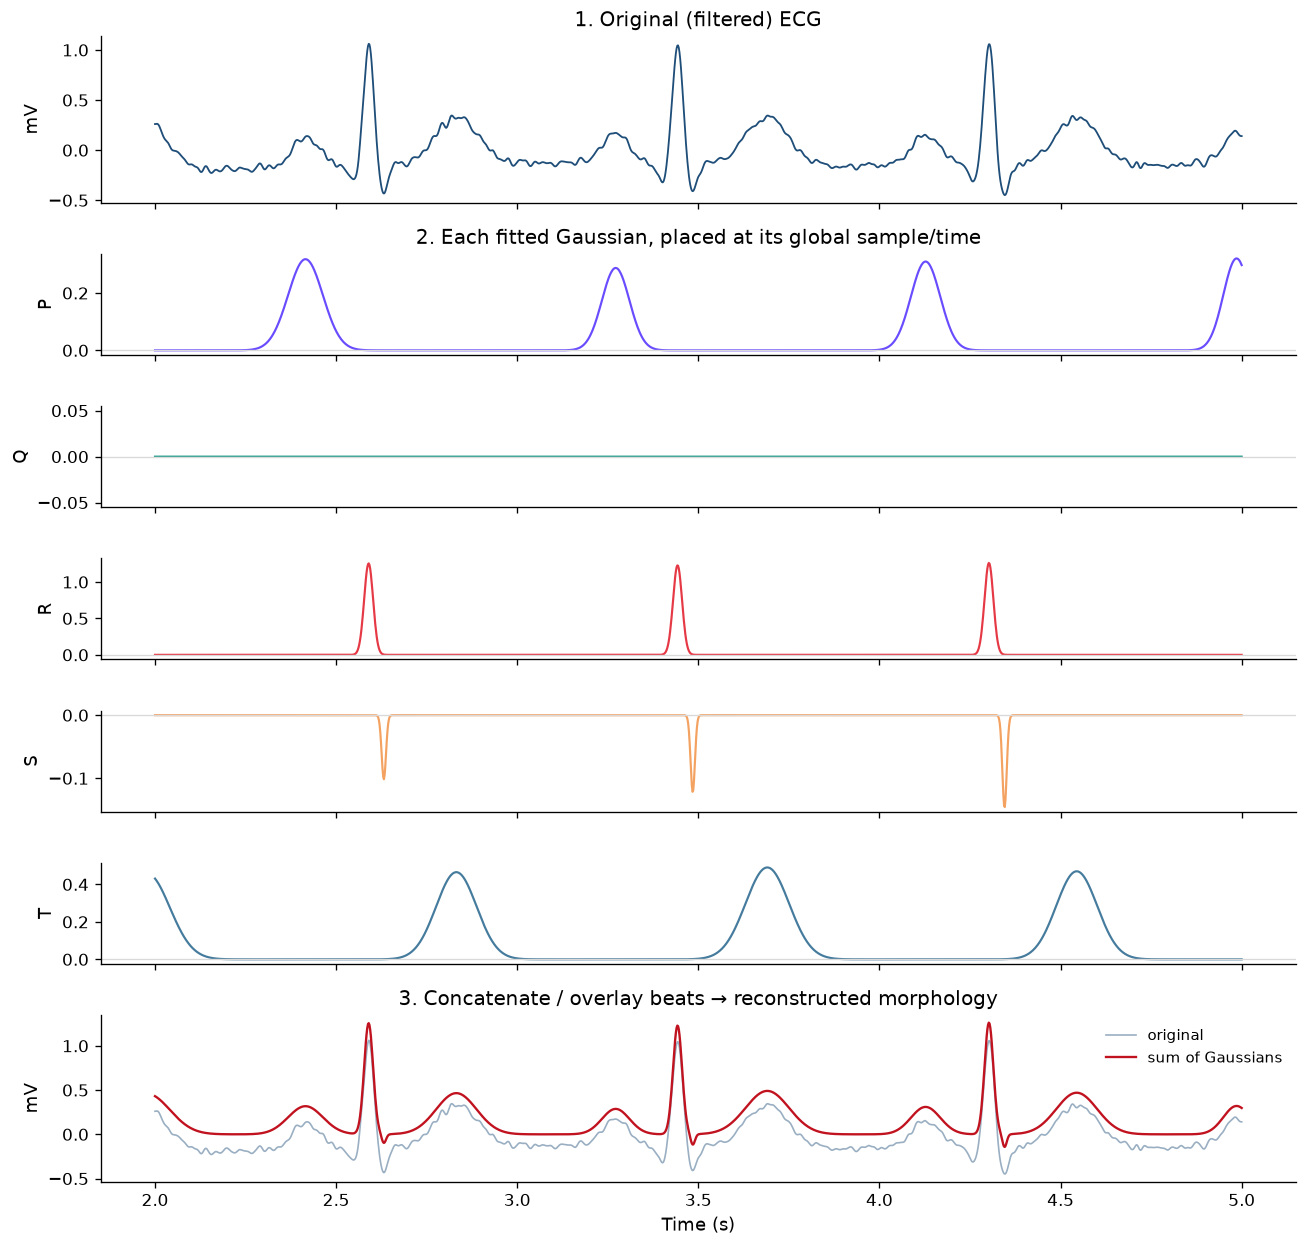

In [7]:
# Stack: original, each wave Gaussian, then the summed mixture.
t0, t1 = ZOOM
m = (recon_time_s >= t0) & (recon_time_s <= t1)
n_panels = 2 + len(WAVE_COLORS)
fig, axes = plt.subplots(
    n_panels, 1, figsize=(11, 10.5), sharex=True,
    gridspec_kw={"height_ratios": [1.4] + [0.85] * len(WAVE_COLORS) + [1.4]},
)

axes[0].plot(recon_time_s[m], filtered[m], color="#1f4e79", lw=1.1)
axes[0].set_ylabel("mV")
axes[0].set_title("1. Original (filtered) ECG")

for i, wave in enumerate(WAVE_COLORS, start=1):
    axes[i].plot(
        recon_time_s[m], recon.components[wave][m],
        color=WAVE_COLORS[wave], lw=1.3,
    )
    axes[i].axhline(0.0, color="0.85", lw=0.8)
    axes[i].set_ylabel(wave)
    if i == 1:
        axes[i].set_title("2. Each fitted Gaussian, placed at its global sample/time")

axes[-1].plot(recon_time_s[m], filtered[m], color="#1f4e79", lw=1.0, alpha=0.45, label="original")
axes[-1].plot(recon_time_s[m], recon.gaussian[m], color="#c1121f", lw=1.4, label="sum of Gaussians")
axes[-1].set_title("3. Concatenate / overlay beats → reconstructed morphology")
axes[-1].set_xlabel("Time (s)")
axes[-1].set_ylabel("mV")
axes[-1].legend(loc="upper right", frameon=False)
fig.tight_layout()
plt.show()


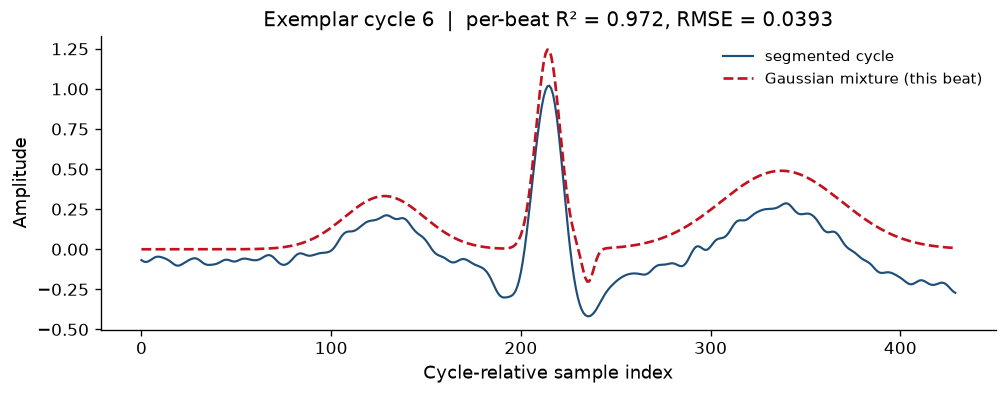

In [8]:
# One exemplar cycle on the cycle-relative axis used by the morphology fit.
cycle_labels = np.sort(cycles["cycle"].unique())
mid = len(features) // 2
row = features.iloc[mid]
label = cycle_labels[mid]
one = cycles.loc[cycles["cycle"] == label]
xs = np.arange(len(one), dtype=float)
cycle_fit = reconstruct_cycle(row, n_samples=len(one), sampling_rate=SAMPLING_RATE_HZ)

fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.plot(xs, one["signal_y"].to_numpy(), color="#1f4e79", lw=1.3, label="segmented cycle")
ax.plot(xs, cycle_fit, color="#c1121f", lw=1.6, ls="--", label="Gaussian mixture (this beat)")
ax.set_title(
    f"Exemplar cycle {mid}  |  per-beat R² = {row['r_squared']:.3f}, "
    f"RMSE = {row['rmse']:.4f}"
)
ax.set_xlabel("Cycle-relative sample index")
ax.set_ylabel("Amplitude")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 5. Original vs reconstructed quality

Compare the filtered recording to the global Gaussian mixture. Residual
(`original − gaussian`) is the leftover the morphology model did not explain
(high-frequency noise, baseline, and any wave-shape mismatch).


In [9]:
def quality_metrics(observed, predicted, prefix=""):
    y = np.asarray(observed, dtype=float)
    yhat = np.asarray(predicted, dtype=float)
    n = min(y.size, yhat.size)
    y, yhat = y[:n], yhat[:n]
    finite = np.isfinite(y) & np.isfinite(yhat)
    y, yhat = y[finite], yhat[finite]
    resid = y - yhat
    r = float(np.corrcoef(y, yhat)[0, 1]) if y.size > 1 else np.nan
    ss_res = float(np.sum(resid**2))
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rmse = float(np.sqrt(np.mean(resid**2)))
    mae = float(np.mean(np.abs(resid)))
    snr = (
        20.0 * np.log10(np.std(y) / np.std(resid))
        if np.std(resid) > 0
        else np.inf
    )
    return pd.Series(
        {
            f"{prefix}pearson_r": r,
            f"{prefix}r_squared": r2,
            f"{prefix}rmse": rmse,
            f"{prefix}mae": mae,
            f"{prefix}snr_db": snr,
            f"{prefix}n_samples": int(y.size),
        }
    )


n = min(filtered.size, recon.gaussian.size)
obs, pred = filtered[:n], recon.gaussian[:n]
global_metrics = quality_metrics(obs, pred)

# Restrict to samples that fall inside a retained cycle window.
covered = np.zeros(n, dtype=bool)
if "index" in cycles.columns:
    idx = cycles["index"].to_numpy(dtype=int)
    idx = idx[(idx >= 0) & (idx < n)]
    covered[idx] = True
covered_metrics = quality_metrics(obs[covered], pred[covered], prefix="cycle_window_")

metrics = pd.concat([global_metrics, covered_metrics])
metrics["median_cycle_r_squared"] = float(features["r_squared"].median())
metrics["median_cycle_rmse"] = float(features["rmse"].median())
metrics["mean_cycle_r_squared"] = float(features["r_squared"].mean())

print("Reconstruction quality (original vs Gaussian mixture)")
display(metrics.to_frame("value").round(4))


Reconstruction quality (original vs Gaussian mixture)


,value
pearson_r,0.8806
r_squared,0.3308
rmse,0.2222
mae,0.1829
snr_db,6.4467
n_samples,6000.0000
cycle_window_pearson_r,0.9694
cycle_window_r_squared,0.4565
cycle_window_rmse,0.1782
cycle_window_mae,0.1681


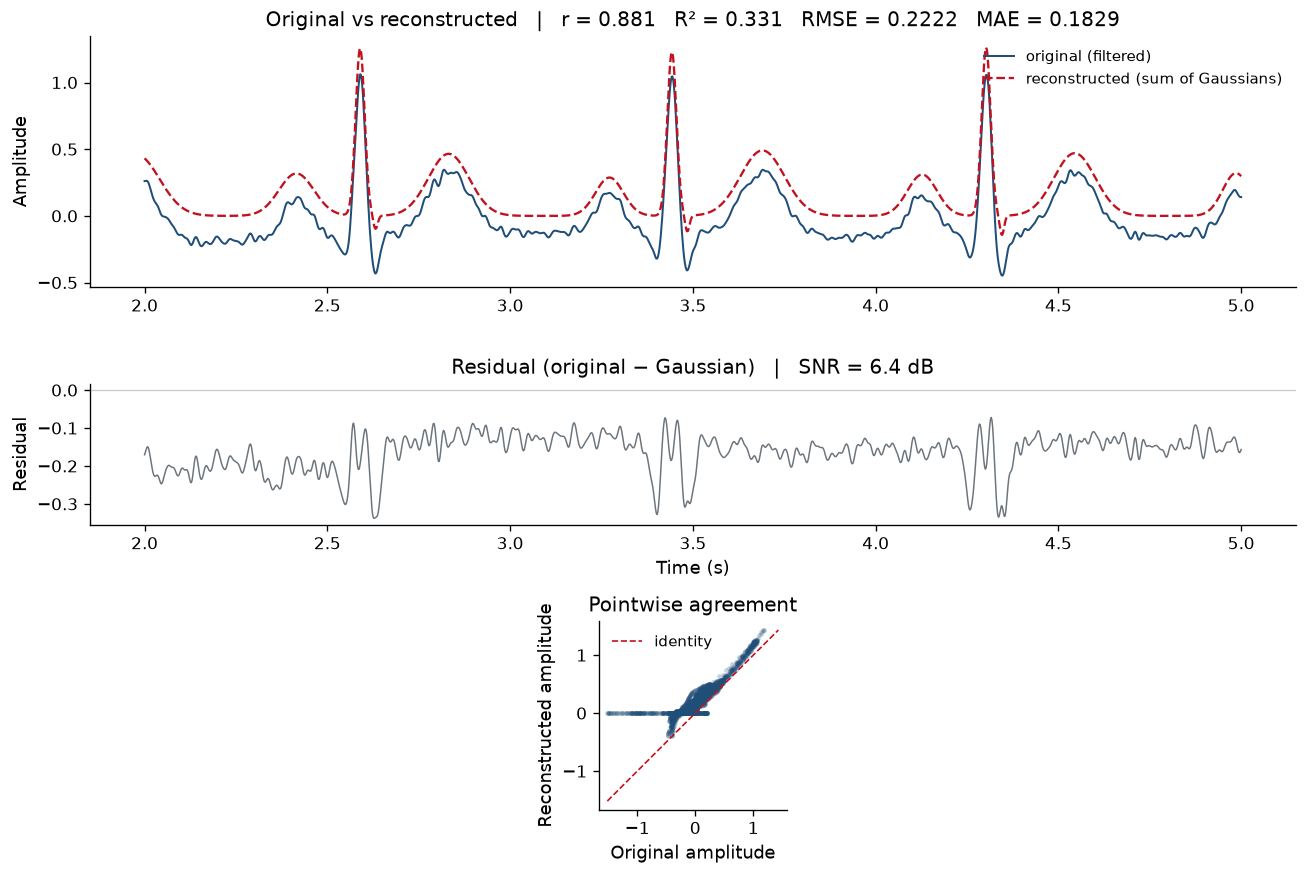

In [10]:
resid = obs - pred
fig, axes = plt.subplots(
    3, 1, figsize=(11, 7.4), sharex=False,
    gridspec_kw={"height_ratios": [1.6, 0.9, 1.2]},
)

mask = (time_s[:n] >= ZOOM[0]) & (time_s[:n] <= ZOOM[1])
axes[0].plot(time_s[:n][mask], obs[mask], color="#1f4e79", lw=1.2, label="original (filtered)")
axes[0].plot(
    time_s[:n][mask], pred[mask], color="#c1121f", lw=1.4, ls="--",
    label="reconstructed (sum of Gaussians)",
)
r = metrics["pearson_r"]
r2 = metrics["r_squared"]
rmse = metrics["rmse"]
axes[0].set_title(
    f"Original vs reconstructed   |   r = {r:.3f}   R² = {r2:.3f}   "
    f"RMSE = {rmse:.4f}   MAE = {metrics['mae']:.4f}"
)
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc="upper right", frameon=False)

axes[1].plot(time_s[:n][mask], resid[mask], color="#6c757d", lw=0.9)
axes[1].axhline(0.0, color="0.8", lw=0.8)
axes[1].set_title(f"Residual (original − Gaussian)   |   SNR = {metrics['snr_db']:.1f} dB")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Residual")

# Scatter uses a subsample so the cloud stays readable.
step = max(1, n // 4000)
axes[2].scatter(obs[::step], pred[::step], s=8, alpha=0.25, color="#1f4e79", linewidths=0)
lo = float(np.nanmin([obs.min(), pred.min()]))
hi = float(np.nanmax([obs.max(), pred.max()]))
axes[2].plot([lo, hi], [lo, hi], color="#c1121f", lw=1.0, ls="--", label="identity")
axes[2].set_xlabel("Original amplitude")
axes[2].set_ylabel("Reconstructed amplitude")
axes[2].set_title("Pointwise agreement")
axes[2].legend(frameon=False)
axes[2].set_aspect("equal", adjustable="box")
fig.tight_layout()
plt.show()


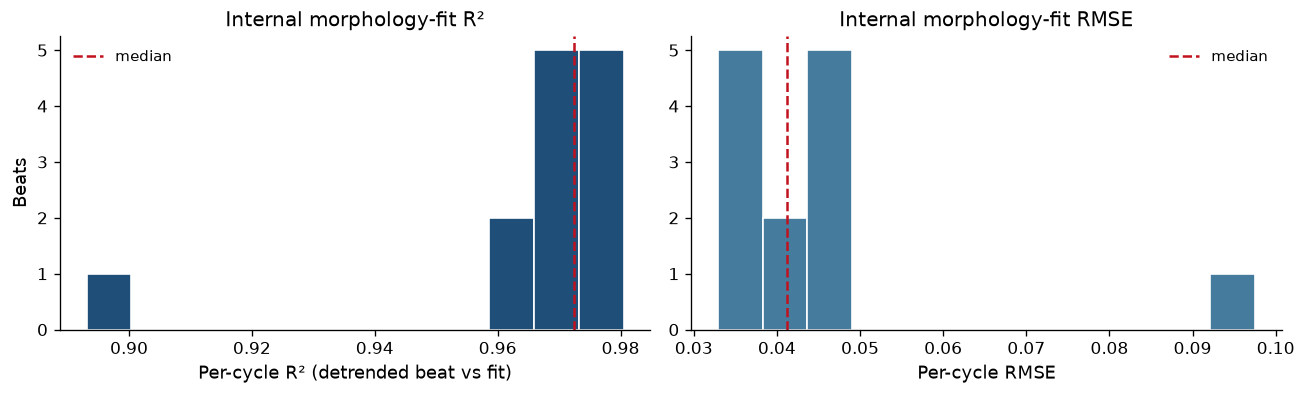

Note: per-cycle R²/RMSE are computed on the detrended beat window used by curve_fit. Full-record R²/RMSE include baseline segments between waves, so they are usually a bit lower.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(features["r_squared"].dropna(), bins=12, color="#1f4e79", edgecolor="white")
axes[0].axvline(features["r_squared"].median(), color="#c1121f", ls="--", label="median")
axes[0].set_xlabel("Per-cycle R² (detrended beat vs fit)")
axes[0].set_ylabel("Beats")
axes[0].set_title("Internal morphology-fit R²")
axes[0].legend(frameon=False)

axes[1].hist(features["rmse"].dropna(), bins=12, color="#457B9D", edgecolor="white")
axes[1].axvline(features["rmse"].median(), color="#c1121f", ls="--", label="median")
axes[1].set_xlabel("Per-cycle RMSE")
axes[1].set_title("Internal morphology-fit RMSE")
axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

print(
    "Note: per-cycle R²/RMSE are computed on the detrended beat window used by "
    "curve_fit. Full-record R²/RMSE include baseline segments between waves, so "
    "they are usually a bit lower."
)
